In [1]:
!pip install pyspark


In [2]:
import pyspark
print(pyspark.__version__)

4.0.3


In [3]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("RailwayDataEngineering") \
    .getOrCreate()

print("Spark Session Created Successfully")

Spark Session Created Successfully


In [4]:
from google.colab import files
files.upload()

Saving Railway_info.csv to Railway_info.csv


{'Railway_info.csv': b'"Train_No","Train_Name","Source_Station_Name","Destination_Station_Name","days"\r\n"107","SWV-MAO-VLNK","SAWANTWADI ROAD","MADGOAN JN.","Saturday"\r\n"108","VLNK-MAO-SWV","MADGOAN JN.","SAWANTWADI ROAD","Friday"\r\n"128","MAO-KOP SPEC","MADGOAN JN.","CHHATRAPATI SHAHU MAHARAJ TERMINUS","Friday"\r\n"290","PALACE ON WH","DELHI-SAFDAR JANG","DELHI-SAFDAR JANG","Wednesday"\r\n"401","BSB BHARATDA","AURANGABAD","VARANASI JN.","Saturday"\r\n"421","LKO-SVDK FTR","LUCKNOW JN.","SHRI MATA VAISHNO DEVI KATRA","Tuesday"\r\n"422","SVDK-LKO FTR","SHRI MATA VAISHNO DEVI KATRA","LUCKNOW JN.","Monday"\r\n"477","FTR TRAIN NO","SIRSA","SIRSA","Sunday"\r\n"502","RJPB-UMB FTR","RAJENDRANAGAR TERMINAL","AMBALA CANTT JN","Monday"\r\n"504","PNBE-BTI FTR","PATNA JN.","BATHINDA JN","Wednesday"\r\n"506","PNBE-PTA FTR","PATNA JN.","PATIALA","Friday"\r\n"557","RSD-PJP BSF","URKURA","PANJIPARA","Wednesday"\r\n"22439","SVDK VANDEBHARAT","NEW DELHI","SHMATA VD KATRA","Friday"\r\n"604","PNBE-ASR

In [5]:
import os
os.listdir("/content")

['.config', 'Railway_info.csv', 'sample_data']

In [6]:
# Level 1: Data Exploration and Basic Operations
# Task 1.1: Load and Inspect Data
# Load the dataset and display the first 10 rows.
# Understand the basic structure of the data, including data types and missing values.

df = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv("/content/Railway_info.csv")

df.show(10, truncate=False)

+--------+------------+----------------------------+----------------------------------+---------+
|Train_No|Train_Name  |Source_Station_Name         |Destination_Station_Name          |days     |
+--------+------------+----------------------------+----------------------------------+---------+
|107     |SWV-MAO-VLNK|SAWANTWADI ROAD             |MADGOAN JN.                       |Saturday |
|108     |VLNK-MAO-SWV|MADGOAN JN.                 |SAWANTWADI ROAD                   |Friday   |
|128     |MAO-KOP SPEC|MADGOAN JN.                 |CHHATRAPATI SHAHU MAHARAJ TERMINUS|Friday   |
|290     |PALACE ON WH|DELHI-SAFDAR JANG           |DELHI-SAFDAR JANG                 |Wednesday|
|401     |BSB BHARATDA|AURANGABAD                  |VARANASI JN.                      |Saturday |
|421     |LKO-SVDK FTR|LUCKNOW JN.                 |SHRI MATA VAISHNO DEVI KATRA      |Tuesday  |
|422     |SVDK-LKO FTR|SHRI MATA VAISHNO DEVI KATRA|LUCKNOW JN.                       |Monday   |
|477     |FTR TRAIN 

In [7]:
df.printSchema()

root
 |-- Train_No: integer (nullable = true)
 |-- Train_Name: string (nullable = true)
 |-- Source_Station_Name: string (nullable = true)
 |-- Destination_Station_Name: string (nullable = true)
 |-- days: string (nullable = true)



In [8]:
from pyspark.sql.functions import col, sum

df.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
]).show()

+--------+----------+-------------------+------------------------+----+
|Train_No|Train_Name|Source_Station_Name|Destination_Station_Name|days|
+--------+----------+-------------------+------------------------+----+
|       0|         0|                  0|                       0|   0|
+--------+----------+-------------------+------------------------+----+



In [9]:
# Task 1.2: Basic Statistics
# Calculate basic statistics such as the number of trains, unique source stations, and unique destination stations.
# Find the most common source and destination stations.

# Total number of trains
total_trains = df.select("Train_No").distinct().count()
print("Total number of trains:", total_trains)
# Unique source stations
unique_sources = df.select("Source_Station_Name").distinct().count()
print("Unique source stations:", unique_sources)
# Unique destination stations
unique_destinations = df.select("Destination_Station_Name").distinct().count()
print("Unique destination stations:", unique_destinations)
# Most common source station
df.groupBy("Source_Station_Name") \
  .count() \
  .orderBy("count", ascending=False) \
  .show(1, truncate=False)
# Most common destination station
df.groupBy("Destination_Station_Name") \
  .count() \
  .orderBy("count", ascending=False) \
  .show(1, truncate=False)


Total number of trains: 11113
Unique source stations: 921
Unique destination stations: 924
+-------------------+-----+
|Source_Station_Name|count|
+-------------------+-----+
|CST-MUMBAI         |513  |
+-------------------+-----+
only showing top 1 row
+------------------------+-----+
|Destination_Station_Name|count|
+------------------------+-----+
|CST-MUMBAI              |514  |
+------------------------+-----+
only showing top 1 row


In [10]:
# Task 1.3: Data Cleaning
# Identify and handle missing values in the dataset.
# Standardize the format of station names (e.g., make all names uppercase).

# Identify Missing Values
from pyspark.sql.functions import col,sum,upper,trim

df.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
]).show()
# Handle Missing values
# Drop rows with critical nulls
df_clean = df.dropna(
    subset=["Source_Station_Name", "Destination_Station_Name"]
)
# Fill nulls
df_clean = df.fillna({
    "Source_Station_Name": "UNKNOWN",
    "Destination_Station_Name": "UNKNOWN"
})
# Standardize Station Names (Uppercase + Trim)
df_clean = df_clean.withColumn(
    "Source_Station_Name",
    upper(trim(col("Source_Station_Name")))
).withColumn(
    "Destination_Station_Name",
    upper(trim(col("Destination_Station_Name")))
)
# Verify Cleaning
df_clean.select(
    "Source_Station_Name",
    "Destination_Station_Name"
).show(5, truncate=False)

+--------+----------+-------------------+------------------------+----+
|Train_No|Train_Name|Source_Station_Name|Destination_Station_Name|days|
+--------+----------+-------------------+------------------------+----+
|       0|         0|                  0|                       0|   0|
+--------+----------+-------------------+------------------------+----+

+-------------------+----------------------------------+
|Source_Station_Name|Destination_Station_Name          |
+-------------------+----------------------------------+
|SAWANTWADI ROAD    |MADGOAN JN.                       |
|MADGOAN JN.        |SAWANTWADI ROAD                   |
|MADGOAN JN.        |CHHATRAPATI SHAHU MAHARAJ TERMINUS|
|DELHI-SAFDAR JANG  |DELHI-SAFDAR JANG                 |
|AURANGABAD         |VARANASI JN.                      |
+-------------------+----------------------------------+
only showing top 5 rows


In [11]:
# Task 2.1: Data Filtering
# Filter the data to show trains that operate on specific days (e.g., only on Saturdays).
# Extract and create a new dataframe for trains that start from a specific station.

#Filter Trains That Operate on a Specific Day (Saturday)
from pyspark.sql.functions import col
saturday_trains = df_clean.filter(col("days") == "Saturday")
saturday_trains.show(10, truncate=False)
# Filter Trains Starting From a Specific Station
source_station = "MADGOAN JN."
trains_from_station = df_clean.filter(
    col("Source_Station_Name") == source_station
)
trains_from_station.show(10, truncate=False)
# Extract and create a new dataframe for trains that start from a specific station.
source_station = "MADGOAN JN."
df_trains_from_station = df_clean.filter(
    col("Source_Station_Name") == source_station
)
df_trains_from_station.show(10, truncate=False)

+--------+------------+--------------------+------------------------+--------+
|Train_No|Train_Name  |Source_Station_Name |Destination_Station_Name|days    |
+--------+------------+--------------------+------------------------+--------+
|107     |SWV-MAO-VLNK|SAWANTWADI ROAD     |MADGOAN JN.             |Saturday|
|401     |BSB BHARATDA|AURANGABAD          |VARANASI JN.            |Saturday|
|1196    |NGP-KRMI SPL|NAGPUR JN.(CR)      |KARMALI                 |Saturday|
|1706    |JBP-BDTS SF |JABALPUR            |BANDRA TERMINUS         |Saturday|
|2834    |SRC-RJT SF A|SANTRAGACHI JN.     |RAJKOT                  |Saturday|
|3305    |DHN-KUSUNDA |DHANBAD JN.         |KUSUNDA                 |Saturday|
|3502    |ANVT-JSME BI|ANAND VIHAR TERMINAL|JASIDIH JN.             |Saturday|
|4802    |MKN PBC PASS|MAKRANA JN.         |PARVATSAR CITY          |Saturday|
|5066    |LJN-CPR-EXP |LUCKNOW JN.         |CHHAPRA JN.             |Saturday|
|5306    |FBD- CPA EXP|FARRUKHABAD JN      |KANPUR A

In [12]:
# Task 2.2: Grouping and Aggregation
# Group the data by source station and count the number of trains originating from each station.
# Find the average number of trains per day for each source station.

# Group by Source Station and Count Trains
from pyspark.sql.functions import col,avg
trains_per_source = df_clean.groupBy("Source_Station_Name") \
    .count() \
    .withColumnRenamed("count", "Total_Trains")
trains_per_source.show(10, truncate=False)
# Average Number of Trains per Day for Each Source Station
# step 1: Count Trains per Source Station per Day
trains_per_station_day = df_clean.groupBy(
    "Source_Station_Name", "days"
).count()
# Step 2: Calculate Average Trains per Day per Station
avg_trains_per_day = trains_per_station_day.groupBy(
    "Source_Station_Name"
).agg(
    avg("count").alias("Avg_Trains_Per_Day")
)
avg_trains_per_day.show(10, truncate=False)

+-------------------+------------+
|Source_Station_Name|Total_Trains|
+-------------------+------------+
|PILIBHIT JN.       |18          |
|JAKHAL JN.         |2           |
|BHILDI JN          |1           |
|INDORE BG          |41          |
|ARAMBAG            |13          |
|CHHEOKI            |1           |
|KASHIPUR JN        |5           |
|UDHAGAMANDALAM     |4           |
|AMBALA CANTT JN    |29          |
|MUNABAO            |2           |
+-------------------+------------+
only showing top 10 rows
+-------------------+------------------+
|Source_Station_Name|Avg_Trains_Per_Day|
+-------------------+------------------+
|PILIBHIT JN.       |1.6363636363636365|
|BHILDI JN          |1.0               |
|JAKHAL JN.         |2.0               |
|ARAMBAG            |2.1666666666666665|
|KASHIPUR JN        |1.25              |
|INDORE BG          |5.857142857142857 |
|UDHAGAMANDALAM     |1.3333333333333333|
|CHHEOKI            |1.0               |
|AMBALA CANTT JN    |4.14285714285

In [13]:
# Task 2.3: Data Enrichment
# Add a new column that categorizes trains based on their operating days (e.g., 'Weekday', 'Weekend').
from pyspark.sql.functions import col, when
df_enriched = df_clean.withColumn(
    "Train_Category",
    when(col("days").isin("Saturday", "Sunday"), "Weekend")
    .otherwise("Weekday")
)
df_enriched.select(
    "Train_No",
    "Source_Station_Name",
    "days",
    "Train_Category"
).show(10, truncate=False)

+--------+----------------------------+---------+--------------+
|Train_No|Source_Station_Name         |days     |Train_Category|
+--------+----------------------------+---------+--------------+
|107     |SAWANTWADI ROAD             |Saturday |Weekend       |
|108     |MADGOAN JN.                 |Friday   |Weekday       |
|128     |MADGOAN JN.                 |Friday   |Weekday       |
|290     |DELHI-SAFDAR JANG           |Wednesday|Weekday       |
|401     |AURANGABAD                  |Saturday |Weekend       |
|421     |LUCKNOW JN.                 |Tuesday  |Weekday       |
|422     |SHRI MATA VAISHNO DEVI KATRA|Monday   |Weekday       |
|477     |SIRSA                       |Sunday   |Weekend       |
|502     |RAJENDRANAGAR TERMINAL      |Monday   |Weekday       |
|504     |PATNA JN.                   |Wednesday|Weekday       |
+--------+----------------------------+---------+--------------+
only showing top 10 rows


+----------+-----+
|      days|count|
+----------+-----+
|    Friday| 1471|
|   Tuesday| 1454|
| Wednesday| 1448|
|  Saturday| 1441|
|    Sunday| 1432|
|  Thursday| 1372|
|    Monday| 1342|
|   Fridayd|  178|
|  Tuesdayd|  174|
|   Sundayd|  170|
|Wednesdayd|  164|
|   Mondayd|  161|
| Thursdayd|  154|
| Saturdayd|  152|
+----------+-----+



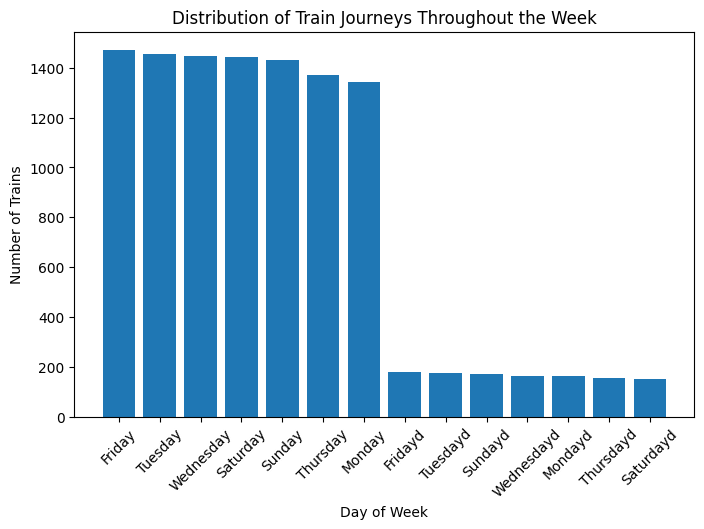

+-------------------+------------------------+-----+
|Source_Station_Name|Destination_Station_Name|count|
+-------------------+------------------------+-----+
|TAMBARAM           |CHENNAI BEACH           |137  |
|CHENNAI BEACH      |TAMBARAM                |137  |
|CST-MUMBAI         |PANVEL                  |94   |
|PANVEL             |CST-MUMBAI              |93   |
|RAVLI JN           |CST-MUMBAI              |90   |
|CST-MUMBAI         |RAVLI JN                |90   |
|VELACHEERY         |CHENNAI BEACH           |89   |
|CHENNAI BEACH      |VELACHEERY              |87   |
|CST-MUMBAI         |THANE                   |77   |
|THANE              |CST-MUMBAI              |72   |
+-------------------+------------------------+-----+
only showing top 10 rows
+-------------------+-----+
|Source_Station_Name|count|
+-------------------+-----+
|CST-MUMBAI         |513  |
|SEALDAH            |372  |
|CHENNAI BEACH      |339  |
|HOWRAH JN.         |338  |
|KALYAN JN          |285  |
|THANE   

In [26]:
# ==========================================================
# Task 3.1: Pattern Analysis
# ==========================================================

import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1. Distribution of Train Journeys Throughout the Week
# ----------------------------------------------------------

trains_per_day = (
    df_enriched
    .groupBy("days")
    .count()
    .orderBy("count", ascending=False)
)

trains_per_day.show()

# Convert PySpark DataFrame to Pandas for visualization
pdf_trains_per_day = trains_per_day.toPandas()

# Create bar chart
plt.figure(figsize=(8, 5))

plt.bar(
    pdf_trains_per_day["days"],
    pdf_trains_per_day["count"]
)

plt.xlabel("Day of Week")
plt.ylabel("Number of Trains")
plt.title("Distribution of Train Journeys Throughout the Week")
plt.xticks(rotation=45)

plt.show()


# ----------------------------------------------------------
# 2. Identify Top Source-Destination Routes
# ----------------------------------------------------------

top_routes = (
    df_enriched
    .groupBy(
        "Source_Station_Name",
        "Destination_Station_Name"
    )
    .count()
    .orderBy("count", ascending=False)
)

top_routes.show(10, truncate=False)


# ----------------------------------------------------------
# 3. Identify Top Source Stations
# ----------------------------------------------------------

top_sources = (
    df_enriched
    .groupBy("Source_Station_Name")
    .count()
    .orderBy("count", ascending=False)
)

top_sources.show(10, truncate=False)

In [15]:
# Task 3.2: Correlation and Insights
# Explore if there is any correlation between the number of trains and specific days of the week.
# Provide insights and recommendations based on the analysis.


from pyspark.sql.functions import (
    regexp_replace, trim, initcap,
    when, col, count, lit
)
# Step 1: Clean day names
df_clean = df_enriched.withColumn(
    "days_clean",
    initcap(trim(regexp_replace("days", "d$", "")))
)
# Step 2: Assign numeric values to days
df_clean = df_clean.withColumn(
    "day_number",
    when(col("days_clean") == "Monday", 1)
    .when(col("days_clean") == "Tuesday", 2)
    .when(col("days_clean") == "Wednesday", 3)
    .when(col("days_clean") == "Thursday", 4)
    .when(col("days_clean") == "Friday", 5)
    .when(col("days_clean") == "Saturday", 6)
    .when(col("days_clean") == "Sunday", 7)
)
# Step 3: Count trains per day
trains_per_day = (
    df_clean
    .groupBy("days_clean", "day_number")
    .agg(count(lit(1)).alias("train_count"))
    .orderBy("day_number")
)
trains_per_day.show()
# Step 4: Calculate correlation
correlation_value = trains_per_day.stat.corr(
    "day_number",
    "train_count"
)
print("Correlation between day of week and number of trains:", correlation_value)
# Step 5: Weekday vs Weekend comparison
df_final = df_clean.withColumn(
    "day_type",
    when(col("days_clean").isin("Saturday", "Sunday"), "Weekend")
    .otherwise("Weekday")
)

df_final.groupBy("day_type").count().show()

+----------+----------+-----------+
|days_clean|day_number|train_count|
+----------+----------+-----------+
|    Monday|         1|       1503|
|   Tuesday|         2|       1628|
| Wednesday|         3|       1612|
|  Thursday|         4|       1526|
|    Friday|         5|       1649|
|  Saturday|         6|       1593|
|    Sunday|         7|       1602|
+----------+----------+-----------+

Correlation between day of week and number of trains: 0.3805757549252302
+--------+-----+
|day_type|count|
+--------+-----+
| Weekday| 7918|
| Weekend| 3195|
+--------+-----+



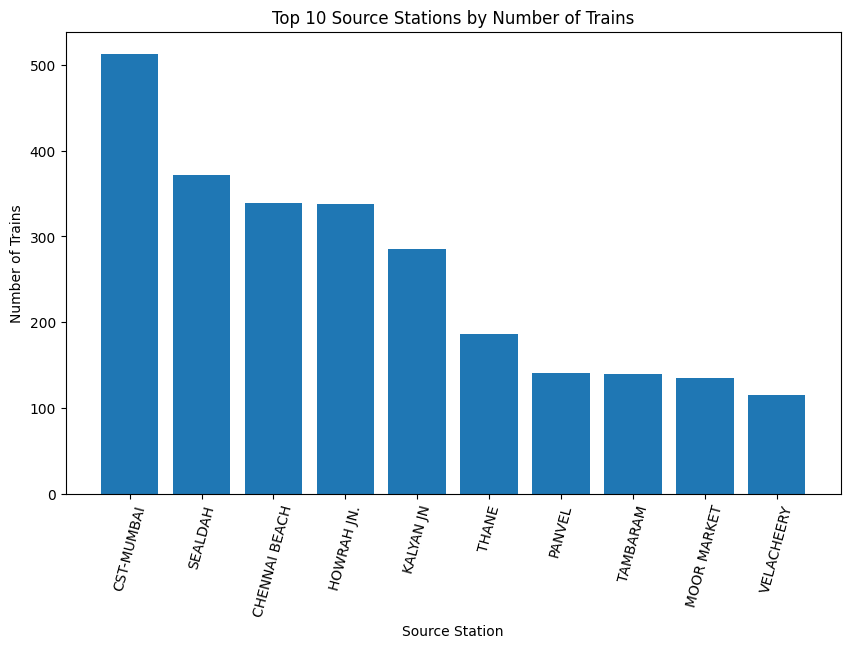

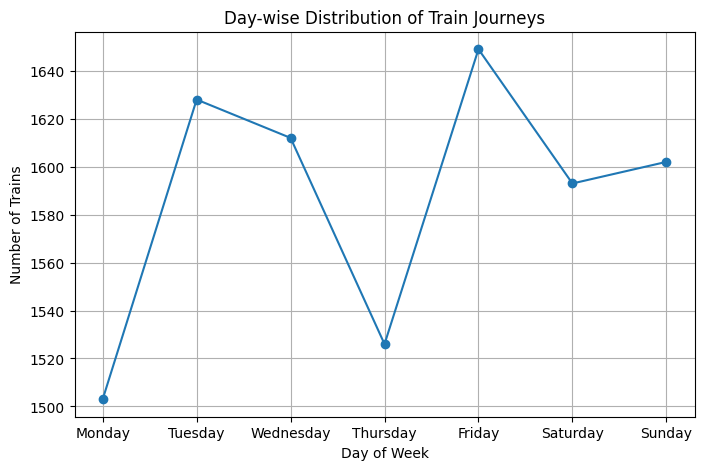

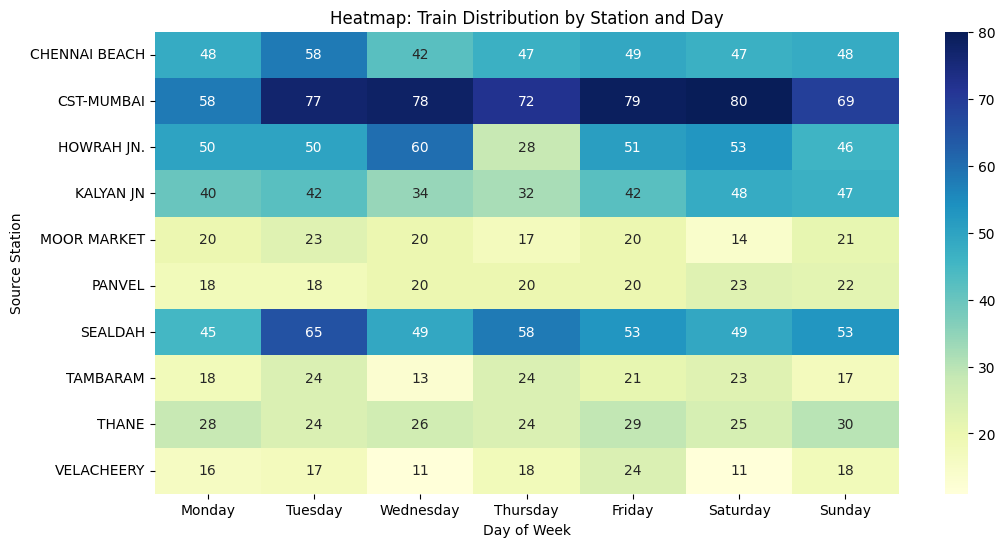


Saved Visualization Files:
--------------------------------
✓ top_source_stations.png created successfully
✓ day_wise_distribution.png created successfully
✓ station_day_heatmap.png created successfully


In [18]:
# ==========================================================
# Level 4: Data Visualization and Reporting
# Task 4.1: Visualization
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# ==========================================================
# 1. BAR CHART – Number of Trains per Source Station
# ==========================================================

trains_per_station = df_final.groupBy("Source_Station_Name") \
    .count() \
    .orderBy("count", ascending=False) \
    .limit(10)

pdf_trains_per_station = trains_per_station.toPandas()

plt.figure(figsize=(10, 6))

plt.bar(
    pdf_trains_per_station["Source_Station_Name"],
    pdf_trains_per_station["count"]
)

plt.xlabel("Source Station")
plt.ylabel("Number of Trains")
plt.title("Top 10 Source Stations by Number of Trains")
plt.xticks(rotation=75)

# Save the bar chart
plt.savefig(
    "/content/top_source_stations.png",
    bbox_inches="tight"
)

plt.show()


# ==========================================================
# 2. LINE CHART – Day-wise Distribution of Trains
# ==========================================================

daywise_trains = df_final.groupBy(
    "days_clean",
    "day_number"
).count().orderBy("day_number")

pdf_daywise_trains = daywise_trains.toPandas()

plt.figure(figsize=(8, 5))

plt.plot(
    pdf_daywise_trains["days_clean"],
    pdf_daywise_trains["count"],
    marker="o"
)

plt.xlabel("Day of Week")
plt.ylabel("Number of Trains")
plt.title("Day-wise Distribution of Train Journeys")
plt.grid(True)

# Save the line chart
plt.savefig(
    "/content/day_wise_distribution.png",
    bbox_inches="tight"
)

plt.show()


# ==========================================================
# 3. HEATMAP – Train Distribution by Station and Day
# ==========================================================

# Get top 10 source stations
top_10_sources = df_final.groupBy(
    "Source_Station_Name"
).count().orderBy(
    "count",
    ascending=False
).limit(10)

# Keep only top 10 stations
heatmap_df = df_final.join(
    top_10_sources.select("Source_Station_Name"),
    on="Source_Station_Name",
    how="inner"
)

# Group by station and day
heatmap_df = heatmap_df.groupBy(
    "Source_Station_Name",
    "days_clean"
).count()

# Convert to Pandas
pdf_heatmap = heatmap_df.toPandas()

# Create pivot table
pivot_table = pdf_heatmap.pivot(
    index="Source_Station_Name",
    columns="days_clean",
    values="count"
).fillna(0)

# Arrange days in correct order
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

pivot_table = pivot_table.reindex(
    columns=day_order,
    fill_value=0
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.xlabel("Day of Week")
plt.ylabel("Source Station")
plt.title("Heatmap: Train Distribution by Station and Day")

# Save the heatmap
plt.savefig(
    "/content/station_day_heatmap.png",
    bbox_inches="tight"
)

plt.show()


# ==========================================================
# 4. INTERACTIVE VISUALIZATION – Plotly
# ==========================================================

fig = px.bar(
    pdf_trains_per_station,
    x="Source_Station_Name",
    y="count",
    title="Interactive View: Top 10 Source Stations",
    labels={
        "count": "Number of Trains",
        "Source_Station_Name": "Source Station"
    }
)

fig.show()


# ==========================================================
# 5. VERIFY ALL IMAGE FILES
# ==========================================================

import os

print("\nSaved Visualization Files:")
print("--------------------------------")

for file in [
    "top_source_stations.png",
    "day_wise_distribution.png",
    "station_day_heatmap.png"
]:
    path = "/content/" + file

    if os.path.exists(path):
        print("✓", file, "created successfully")
    else:
        print("✗", file, "not found")

In [19]:

# ==========================================================
# Level 4 – Task 4.2: Automated Reporting
# ==========================================================

from pyspark.sql.functions import col

print("\n" + "="*70)
print("              RAILWAY DATA ENGINEERING REPORT")
print("="*70)

# ==========================================================
# 1. DATASET SUMMARY
# ==========================================================

total_records = df_final.count()

total_trains = df_final.select(
    "Train_No"
).distinct().count()

unique_sources = df_final.select(
    "Source_Station_Name"
).distinct().count()

unique_destinations = df_final.select(
    "Destination_Station_Name"
).distinct().count()

print("\n📂 DATASET SUMMARY")
print("-"*50)

print(f"Total Records               : {total_records}")
print(f"Total Unique Trains         : {total_trains}")
print(f"Unique Source Stations      : {unique_sources}")
print(f"Unique Destination Stations : {unique_destinations}")


# ==========================================================
# 2. STATION-LEVEL INSIGHTS
# ==========================================================

top_source = df_final.groupBy(
    "Source_Station_Name"
).count().orderBy(
    col("count").desc()
).first()

top_destination = df_final.groupBy(
    "Destination_Station_Name"
).count().orderBy(
    col("count").desc()
).first()

print("\n🚉 STATION INSIGHTS")
print("-"*50)

print(
    f"Top Source Station      : "
    f"{top_source['Source_Station_Name']} "
    f"({top_source['count']} trains)"
)

print(
    f"Top Destination Station : "
    f"{top_destination['Destination_Station_Name']} "
    f"({top_destination['count']} trains)"
)


# ==========================================================
# 3. DAY-WISE TRAIN DISTRIBUTION
# ==========================================================

print("\n📅 DAY-WISE TRAIN DISTRIBUTION")
print("-"*50)

day_distribution = df_final.groupBy(
    "days_clean"
).count().orderBy(
    col("count").desc()
).collect()

for row in day_distribution:
    percentage = (row["count"] / total_records) * 100

    print(
        f"{row['days_clean']:10s} : "
        f"{row['count']:4d} trains "
        f"({percentage:.2f}%)"
    )


# ==========================================================
# 4. WEEKDAY VS WEEKEND ANALYSIS
# ==========================================================

weekday_weekend = df_final.groupBy(
    "day_type"
).count().collect()

print("\n📊 WEEKDAY VS WEEKEND ANALYSIS")
print("-"*50)

for row in weekday_weekend:
    percentage = (row["count"] / total_records) * 100

    print(
        f"{row['day_type']:8s} : "
        f"{row['count']:4d} trains "
        f"({percentage:.2f}%)"
    )


# ==========================================================
# 5. ROUTE ANALYSIS
# ==========================================================

top_route = df_final.groupBy(
    "Source_Station_Name",
    "Destination_Station_Name"
).count().orderBy(
    col("count").desc()
).first()

print("\n🛤️ ROUTE ANALYSIS")
print("-"*50)

print(
    f"Most Frequent Route : "
    f"{top_route['Source_Station_Name']} → "
    f"{top_route['Destination_Station_Name']} "
    f"({top_route['count']} services)"
)


# ==========================================================
# 6. CORRELATION ANALYSIS
# ==========================================================

correlation_value = df_final.groupBy(
    "days_clean",
    "day_number"
).count().orderBy(
    "day_number"
).stat.corr(
    "day_number",
    "count"
)

print("\n📈 CORRELATION ANALYSIS")
print("-"*50)

print(
    f"Correlation between day number "
    f"and train count : {correlation_value:.4f}"
)


# ==========================================================
# 7. KEY INSIGHTS
# ==========================================================

print("\n💡 KEY INSIGHTS")
print("-"*50)

print(
    f"• {unique_sources} unique source stations and "
    f"{unique_destinations} unique destination stations "
    f"were identified."
)

print(
    f"• {top_source['Source_Station_Name']} is the "
    f"top source station with {top_source['count']} services."
)

print(
    f"• {top_destination['Destination_Station_Name']} is the "
    f"top destination station with {top_destination['count']} services."
)

print(
    f"• The most frequent route is "
    f"{top_route['Source_Station_Name']} → "
    f"{top_route['Destination_Station_Name']}."
)

print(
    "• Train services are more concentrated on weekdays "
    "than weekends."
)

print(
    f"• The correlation between day number and train count "
    f"is {correlation_value:.4f}."
)


# ==========================================================
# 8. BUSINESS RECOMMENDATIONS
# ==========================================================

print("\n📌 BUSINESS RECOMMENDATIONS")
print("-"*50)

print("• Optimize scheduling at high-traffic source stations.")
print("• Use day-wise demand patterns for capacity planning.")
print("• Analyze high-frequency routes for service optimization.")
print("• Evaluate weekend demand before adding additional services.")
print("• Focus infrastructure planning on major railway hubs.")


# ==========================================================
# 9. EXECUTIVE SUMMARY
# ==========================================================

print("\n🎯 EXECUTIVE SUMMARY")
print("-"*50)

print(
    "This PySpark-based analysis processed railway operational "
    "data to identify major railway hubs, high-frequency routes, "
    "day-wise service patterns, and weekday versus weekend trends. "
    "The findings can support railway scheduling, capacity planning, "
    "and operational decision-making."
)


# ==========================================================
# END OF REPORT
# ==========================================================

print("\n" + "="*70)
print("                    END OF REPORT")
print("="*70)


              RAILWAY DATA ENGINEERING REPORT

📂 DATASET SUMMARY
--------------------------------------------------
Total Records               : 11113
Total Unique Trains         : 11113
Unique Source Stations      : 921
Unique Destination Stations : 924

🚉 STATION INSIGHTS
--------------------------------------------------
Top Source Station      : CST-MUMBAI (513 trains)
Top Destination Station : CST-MUMBAI (514 trains)

📅 DAY-WISE TRAIN DISTRIBUTION
--------------------------------------------------
Friday     : 1649 trains (14.84%)
Tuesday    : 1628 trains (14.65%)
Wednesday  : 1612 trains (14.51%)
Sunday     : 1602 trains (14.42%)
Saturday   : 1593 trains (14.33%)
Thursday   : 1526 trains (13.73%)
Monday     : 1503 trains (13.52%)

📊 WEEKDAY VS WEEKEND ANALYSIS
--------------------------------------------------
Weekday  : 7918 trains (71.25%)
Weekend  : 3195 trains (28.75%)

🛤️ ROUTE ANALYSIS
--------------------------------------------------
Most Frequent Route : CHENNAI BEACH 

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
